# Vision-Based Saliency Prediction

### What this notebook does:
- Trains the model using configurations defined in `config.py`.
- Tracks training and validation loss dynamically across epochs.
- Evaluates the model on validation metrics defined in `config.py`.
- Visualizes the learning curves automatically using Matplotlib.

SaliencyDataset class defined.

--- Data Preparation Complete ---

==================== Running Experiment: multiscale ====================
Using device: cuda

--- Epoch 1/10 ---


Validating: 100%|██████████| 157/157 [00:58<00:00,  2.69it/s]


Train Loss: 0.0704 | Val Loss: 0.0409 | PCC: 0.8082 | JSS: 0.7743 | MSE: 0.0409
Saved new best model to checkpoints/best_model_multiscale_20260710_143726.pth

--- Epoch 2/10 ---


Validating: 100%|██████████| 157/157 [00:38<00:00,  4.09it/s]


Train Loss: 0.0306 | Val Loss: 0.0229 | PCC: 0.8404 | JSS: 0.7999 | MSE: 0.0229
Saved new best model to checkpoints/best_model_multiscale_20260710_143726.pth

--- Epoch 3/10 ---


...

Train Loss: 0.0076 | Val Loss: 0.0095 | PCC: 0.8631 | JSS: 0.8918 | MSE: 0.0095
Saved new best model to checkpoints/best_model_multiscale_20260710_143726.pth

--- Epoch 9/10 ---


Validating: 100%|██████████| 157/157 [00:48<00:00,  3.24it/s]


Train Loss: 0.0071 | Val Loss: 0.0093 | PCC: 0.8650 | JSS: 0.8978 | MSE: 0.0093
Saved new best model to checkpoints/best_model_multiscale_20260710_143726.pth

--- Epoch 10/10 ---


Validating: 100%|██████████| 157/157 [00:45<00:00,  3.44it/s]


Train Loss: 0.0067 | Val Loss: 0.0091 | PCC: 0.8644 | JSS: 0.9042 | MSE: 0.0091
Saved new best model to checkpoints/best_model_multiscale_20260710_143726.pth


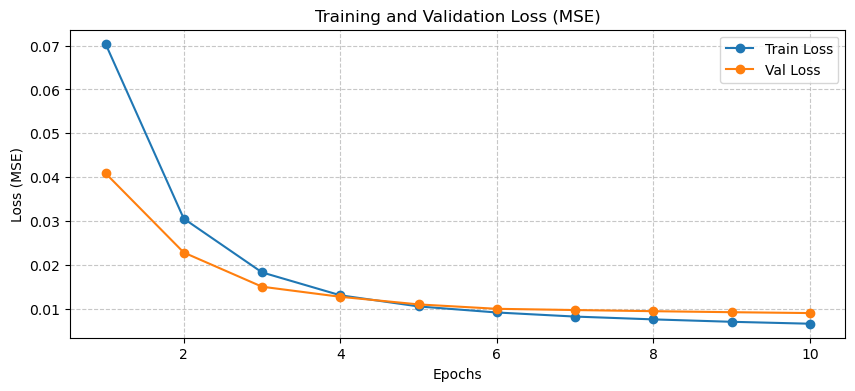

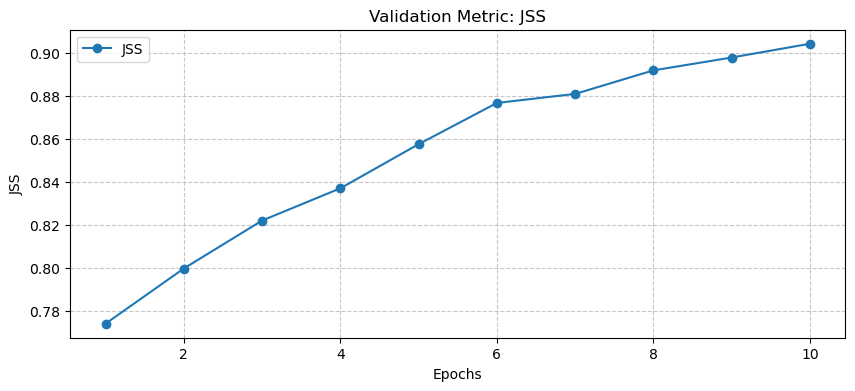

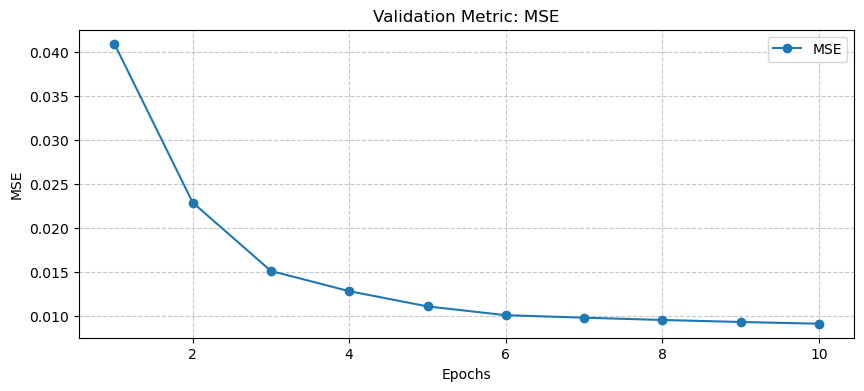

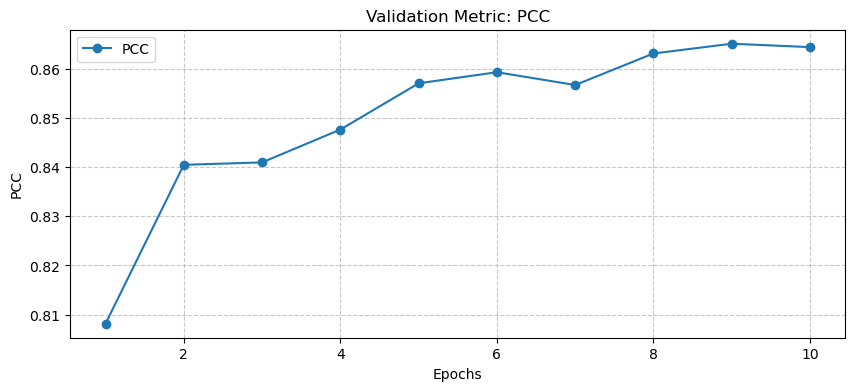


--- Summary of Final Epoch Values (multiscale) ---
Final Train Loss (MSE): 0.0067
Final Val Loss (MSE):   0.0091
Final JSS            : 0.9042
Final MSE            : 0.0091
Final PCC            : 0.8644


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from train import main as train
from config import get_config

# configuration flags
SAVE_PLOTS = True
PLOT_DIR = "plots"

if SAVE_PLOTS:
    os.makedirs(PLOT_DIR, exist_ok=True)

experiments = ["multiscale"] # baseline or multiscale
results = {}

for name in experiments:
    print(f"\n{'='*20} Running Experiment: {name} {'='*20}")
    
    config = get_config(name)
    loss_name = config.loss.name
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    model, history = train(name)
    
    train_losses = history["train_losses"]
    val_results = history["val_losses"]
    val_loss = [epoch_res["val_loss"] for epoch_res in val_results]
    
    # plot train and val loss
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o', color='#1f77b4')
    plt.plot(range(1, len(val_loss) + 1), val_loss, label='Val Loss', marker='o', color='#ff7f0e')
    plt.xlabel('Epochs')
    plt.ylabel(f'Loss ({loss_name})')
    plt.title(f'Training and Validation Loss ({loss_name})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    if SAVE_PLOTS:
        plt.savefig(os.path.join(PLOT_DIR, f"{name}_{timestamp}_loss.png"), bbox_inches='tight')
    plt.show()
    
    # plot all metrics
    all_metrics = set()
    for epoch_res in val_results:
        all_metrics.update([k for k in epoch_res.keys() if k != "val_loss"])
    all_metrics = sorted(list(all_metrics))
    
    for metric in all_metrics:
        metric_vals = [epoch_res[metric] for epoch_res in val_results if metric in epoch_res]
        
        plt.figure(figsize=(10, 4))
        plt.plot(range(1, len(metric_vals) + 1), metric_vals, label=metric, marker='o', color='#1f77b4')
        plt.xlabel('Epochs')
        plt.ylabel(metric)
        plt.title(f'Validation Metric: {metric}')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        if SAVE_PLOTS:
            plt.savefig(os.path.join(PLOT_DIR, f"{name}_{timestamp}_{metric}.png"), bbox_inches='tight')
        plt.show()
        
    # print final losses and metrics
    print(f"\n--- Summary of Final Epoch Values ({name}) ---")
    print(f"Final Train Loss ({loss_name}): {train_losses[-1]:.4f}")
    print(f"Final Val Loss ({loss_name}):   {val_loss[-1]:.4f}")
    for metric in all_metrics:
        metric_vals = [epoch_res[metric] for epoch_res in val_results if metric in epoch_res]
        print(f"Final {metric:<15}: {metric_vals[-1]:.4f}")